In [9]:
import numpy as np
from numpy import linalg as la

# We want to suppress printing of small floating point values using scientific notation
np.set_printoptions(suppress=True)

# 1 
A = np.array([1,2,3, 0,-4,1, 0,3,-1]).reshape(3,3)

print("A=")
print(A)
det = la.det(A)
print(f"Determinant of A is: {det:.6f}")

# 2
b = np.array([2,2,-1])
xyz = la.inv(A).dot(b)
print(f"\nSolution: x, y, z = {xyz}")

# 3
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
# so not orthogonal

# 4
Lambda, v= la.eig(A)
print("Lambda = ", Lambda)

A=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of A is: 1.000000

Solution: x, y, z = [10. -1. -2.]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]
Lambda =  [ 1.         -4.79128785 -0.20871215]


In [6]:
import numpy as np
from numpy import linalg as la

# We want to suppress printing of small floating point values using scientific notation
np.set_printoptions(suppress=True)

a1 = np.radians(180 - 123)  
a2 = np.radians(90 - 27.4) 
a3 = np.radians(192.25)

Ez1 = np.array([np.cos(a1),  np.sin(a1), 0, -np.sin(a1), np.cos(a1), 0,0,  0,  1]).reshape(3,3)

# Ey(62.6)
Ey = np.array([np.cos(a2), 0, -np.sin(a2),0, 1, 0,np.sin(a2), 0, np.cos(a2)]).reshape(3,3)

# Ez(192.25)
Ez2 = np.array([np.cos(a3),  np.sin(a3), 0, -np.sin(a3), np.cos(a3), 0,0,0,1]).reshape(3,3)

# 7.15
E = Ez1 @ Ey @ Ez2

print("E =")
print(E)

# To prove:
# ETxE=I
# det(E)=1

print(f"\nET.E should be the identity matrix:\n{E.T@E}")
det = la.det(E)
print(f"Determinant of E is: {det:.6f}")

# so E is a rotation matrix

# eigenvalue
Lambda, v= la.eig(E)
print("Lambda = ", Lambda)

# v
alpha = np.radians(192.25)
delta = np.radians(27.4)
v = np.array([np.cos(delta)*np.cos(alpha), np.cos(delta)*np.sin(alpha), np.sin(delta)])
print(v)
print("norm= ",la.norm(v))

v2 = E@v
print(v2)

E =
[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

ET.E should be the identity matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
Determinant of E is: 1.000000
Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[-0.86760081 -0.1883746   0.46019978]
norm=  1.0
[0. 0. 1.]


[ 218.5823317  -551.00314537  565.81223644 -313.63355538  104.54407412
  -21.93313592    2.91867714   -0.23905976    0.01099256   -0.00021712]


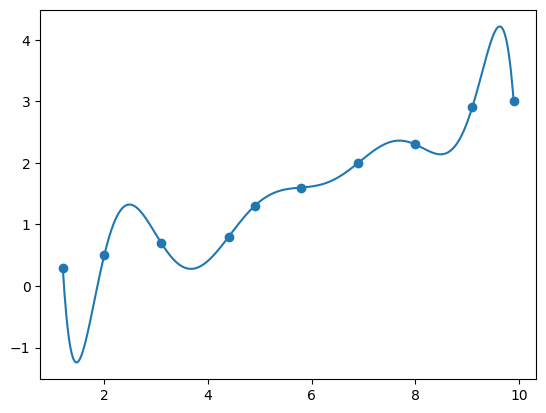

In [23]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
N = len(x)
# Empty matrix
A = np.zeros((N,N))
# fill the matrix with polynomial rows
for i in range(N):
    for j in range(N):
        A[i,j]=x[i]**j
a=la.solve(A,y)
print(a)
x_val = np.linspace(np.min(x),np.max(x),500)

y_val = 0
for i in range(len(a)):
    y_val+= a[i]*x_val**i
plt.scatter(x,y)
plt.plot(x_val,y_val)
plt.show()


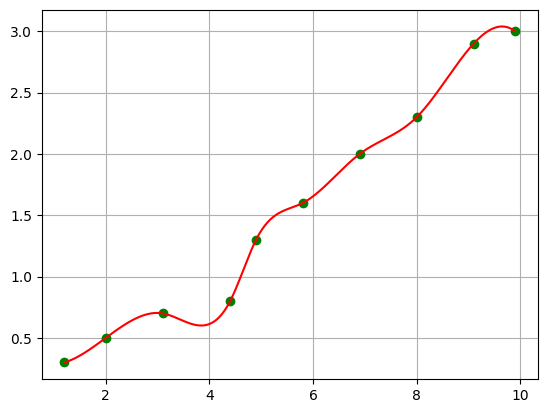

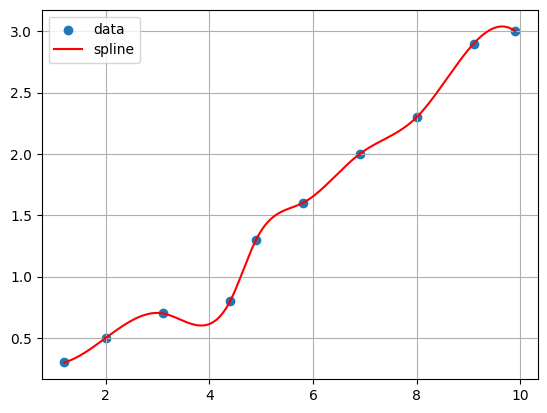

1.5702983236760701


In [25]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(np.min(x),np.max(x),500)
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

class interpolation:
    def __init__(self, x, y):
        self.x=x
        self.y=y
    def linear(self):
        l = ip.interp1d(self.x, self.y, kind='linear')
        return l
    def polynomial(self):
        N = len(self.x)
        A = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                A[i, j] = self.x[i]**j
        a = np.linalg.solve(A, self.y)

        def f(x_val):
            y_val = 0
            for i in range(len(a)):
                y_val += a[i] * x_val**i
            return y_val

        return f
    def spline(self):
        z = ip.interp1d(self.x, self.y, kind= 'cubic')
        return z
    
    def plot(self, method='spline'):
        newx = np.linspace(np.min(self.x), np.max(self.x), 500)

        if method == 'linear':
            f = self.linear()
        elif method == 'polynomial':
            f = self.polynomial()
        elif method == 'spline':
            f = self.spline()
        else:
            raise ValueError("Choose linear, polynomial or spline")

        newy = f(newx)

        plt.figure()
        plt.scatter(self.x, self.y, label='data')
        plt.plot(newx, newy, 'r', label=method)
        plt.grid(True)
        plt.legend()
        plt.show()
        
    def evaluate(self, x_val, method='spline'):
        if method == 'linear':
            f = self.linear()
        elif method == 'polynomial':
            f = self.polynomial()
        elif method == 'spline':
            f = self.spline()
        else:
            raise ValueError("Choose linear, polynomial or spline")

        return f(x_val)
    
interp = interpolation(x, y)

interp.plot('spline')
print(interp.evaluate(5.5, 'polynomial'))

In [27]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

I = np.array([[2.0,4.1], [2.5,3.8]])

print(I)

rowindices = range(I.shape[0])
colindices = range(I.shape[1])

col_x = 0.2
row_y = 0.7

# Interpolator example: https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff
do_interpol = RegularGridInterpolator( (colindices, rowindices), I.T, method='linear')
Iintp = do_interpol ((col_x, row_y) )
print(f"The interpolated intensity at x,y={col_x},{row_y} is {Iintp}")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at x,y=0.2,0.7 is 2.658


====== LEASTSQ RESULTS ==========
Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7

====== CURVE_FIT RESULTS ==========
Params: [69.9377803  64.13234248]
Errors: [47.32288312  1.52711808]


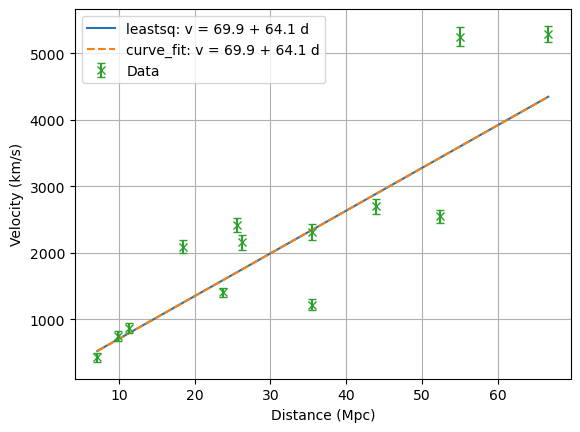

In [25]:
import numpy as np
from scipy.optimize import leastsq, curve_fit
import matplotlib.pyplot as plt

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
data = np.asarray(data)

x = data[0::4]      # afstand (Mpc)
y = data[1::4]      # snelheid (km/s)
sigx = data[2::4]   # fout in afstand 
sigy = data[3::4]   # fout in snelheid

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

# Convert unscaled standard errors to scaled standard errors
# No need to understand this code
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta

def hubble(d, beta0, beta1):
    return beta0 + beta1 * d

popt, pcov = curve_fit(hubble, x, y, sigma=sigy, absolute_sigma=True)

print("\n====== CURVE_FIT RESULTS ==========")
print("Params:", popt)
print("Errors:", np.sqrt(np.diag(pcov)))

x_fit = np.linspace(min(x), max(x), 100)

plt.plot(x_fit, model(beta_lsqwei, x_fit),
         label=f'leastsq: v = {beta[0]:.1f} + {beta[1]:.1f} d')
plt.plot(x_fit, hubble(x_fit, popt[0], popt[1]),
         '--',
         label=f'curve_fit: v = {popt[0]:.1f} + {popt[1]:.1f} d')

plt.errorbar(x, y, yerr=sigy, fmt='x', capsize=3, label='Data')
plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()


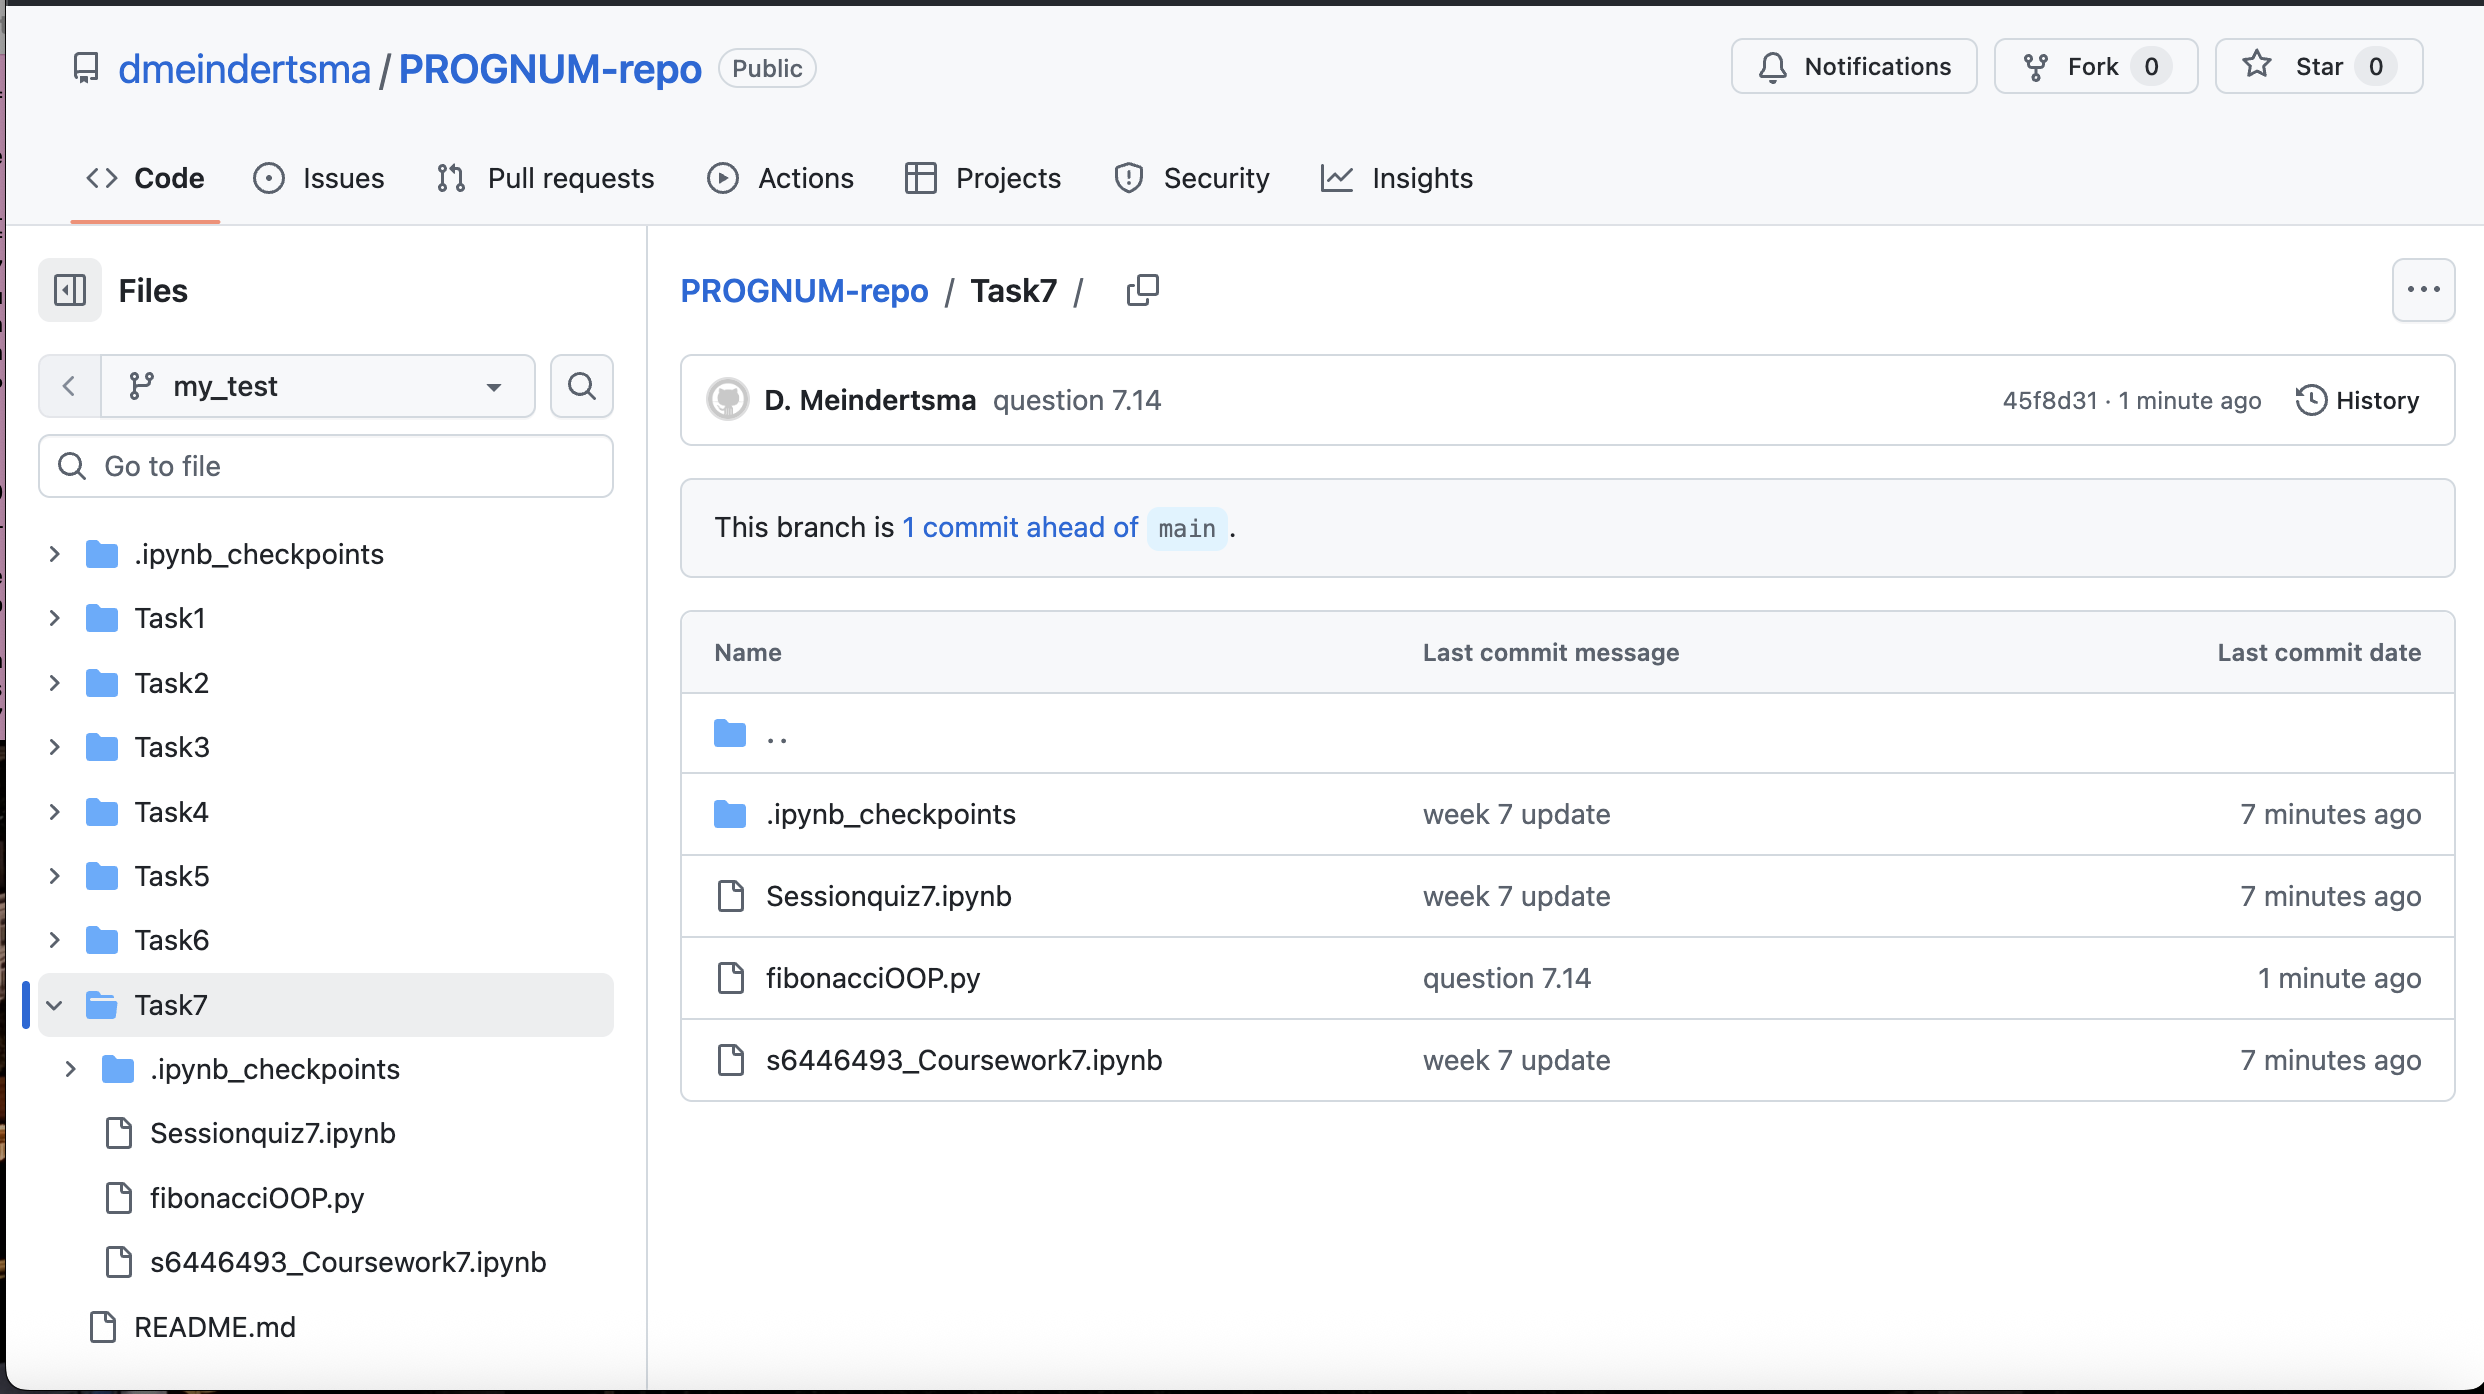